# Module-4_Python_Module_End_Project
#### As a culminating project, you'll be working with a dataset from ABC company, consisting of 458 rows and 9 columns. 
#### The company requires a comprehensive report detailing information about their employees across various teams. 
#### Your tasks include preprocessing the dataset, analyzing the data, and presenting your findings graphically.

In [23]:
import pandas as p

def ensure_data_integrity(filepath):
    # Loading data
    try:
        d = p.read_excel("myexcel.xlsx")
        print("Data loaded successfully.")
    except Exception as e:
        raise ValueError(f"Error loading data: {e}")

    # Check for missing values
    if d.isnull().values.any():
        print("Warning: Missing values detected.")
        print(d.isnull().sum())

    # Check for duplicates
    if d.duplicated().any():
        print("Warning: Duplicate rows detected.")
        d = d.drop_duplicates()

    # Validating data types
    print("\nData Types:")
    print(d.dtypes)

if __name__ == "__main__":
    clean_df = ensure_data_integrity("myexcel.xlsx")

Data loaded successfully.
Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

Data Types:
Name         object
Team         object
Number        int64
Position     object
Age           int64
Height       object
Weight        int64
College      object
Salary      float64
dtype: object


### 1. Correct the data in the "height" column by replacing it with random numbers between 150 and 180.

In [11]:
import pandas as p
import random

d = p.read_excel("myexcel.xlsx")
d.info()
d.isnull().sum()

# Replacing "Height" column with random values between 150 and 180
d['Height'] = [random.randint(150, 180) for _ in range(len(d))]


# Printing the entire DataFrame or a single row in one line
print(d)

# Set the maximum number of columns to be displayed
p.set_option('display.max_columns', None)  # Display all columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB
              Name            Team  Number Position  Age  Height  Weight  \
0    Avery Bradley  Boston Celtics       0       PG   25     171     180   
1      Jae Crowder  Boston Celtics      99       SF   25     168     235   
2     John Holland  Boston Celtics      30       SG   27     175     205   
3      R.J. Hunter  Boston Celtics      28       SG   22     163     185   
4    Jonas Jerebko  Bost

## Analysis Tasks:

### 1. Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.

In [6]:
# Counting employees in each team
Team_Counts = d['Team'].value_counts()

# Calculating percentage
Team_Percentage = (Team_counts / len(d)) * 100

# Displaying results
print("Team Counts:\n", Team_Counts)
print("\nTeam Percentage Split:\n", Team_Percentage)


Team Counts:
 Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

Team Percentage Split:
 Team
New Orleans Pelicans      4.148472
Memphis Grizzlies   

### 2. Segregate employees based on their positions within the company

In [24]:
# Grouping by position and count employees
Position_Counts = d['Position'].value_counts()

# Displaying results
print("Employees by Position:\n", Position_Counts)


Employees by Position:
 Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


### 3. Identify the predominant age group among employees.

In [25]:
# Creating age groups (you can adjust age ranges as needed)
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-30', '30-40', '40-50', '50-60', '60-70']
d['age_group'] = p.cut(d['Age'], bins=bins, labels=labels, right=False)

# Finding the predominant age group
Age_Group_Counts = d['age_group'].value_counts()

# Displaying results
print("Age Group Distribution:\n", Age_Group_Counts)


Age Group Distribution:
 age_group
20-30    334
30-40    119
40-50      3
50-60      0
60-70      0
Name: count, dtype: int64


### 4. Discover which team and position have the highest salary expenditure. 

In [26]:
# Grouping by team and calculate total salary expenditure
Team_Salary = d.groupby('Team')['Salary'].sum()

# Grouping by position and calculate total salary expenditure
Position_Salary = d.groupby('Position')['Salary'].sum()

# Identifying highest salary expenditure
Highest_Team_Salary = Team_Salary.idxmax(), Team_Salary.max()
Highest_Position_Salary = Position_Salary.idxmax(), Position_Salary.max()

print("Highest Salary Expenditure by Team:", Highest_Team_Salary)
print("Highest Salary Expenditure by Position:", Highest_Position_Salary)


Highest Salary Expenditure by Team: ('Cleveland Cavaliers', np.float64(106988689.0))
Highest Salary Expenditure by Position: ('C', np.float64(466377332.0))


### 5. Investigate if there's any correlation between age and salary, and represent it visually.

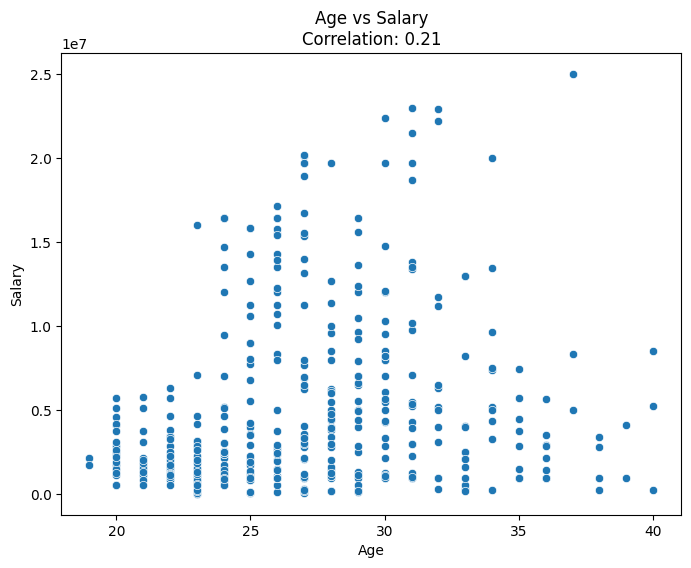

Correlation between Age and Salary: 0.21


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating correlation
Correlation = d['Age'].corr(d['Salary'])

# Visualizing the correlation
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Salary', data=d)
plt.title(f'Age vs Salary\nCorrelation: {Correlation:.2f}')
plt.show()

print(f"Correlation between Age and Salary: {Correlation:.2f}")


## Graphical Representation:

### Employees counts by team using Barchart

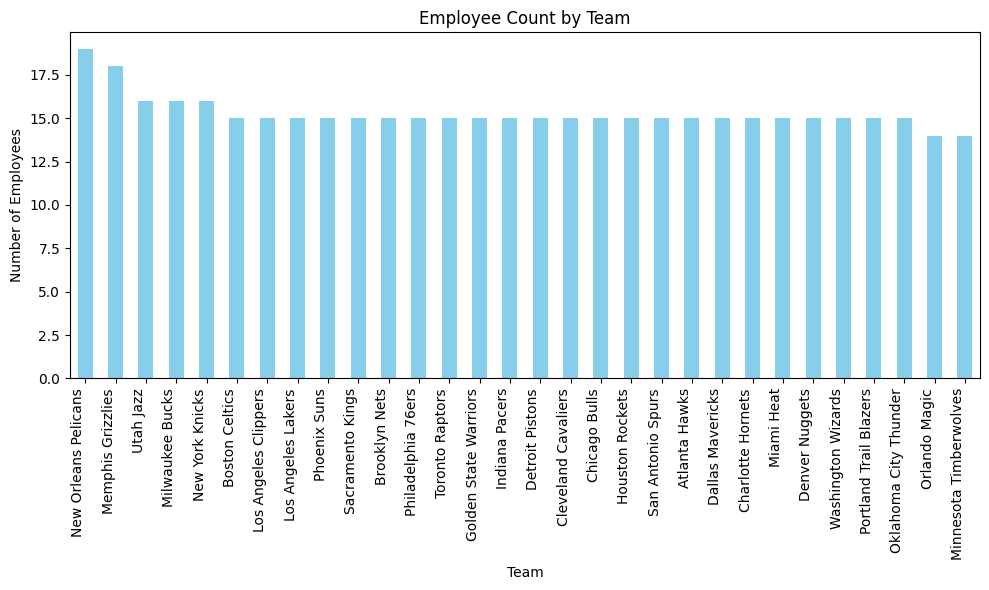

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

Team_Counts = d['Team'].value_counts()

# Bar Chart
plt.figure(figsize=(10, 6))
Team_counts.plot(kind='bar', color='skyblue')
plt.title('Employee Count by Team')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()



### Employee Distribution by Team using Piechart

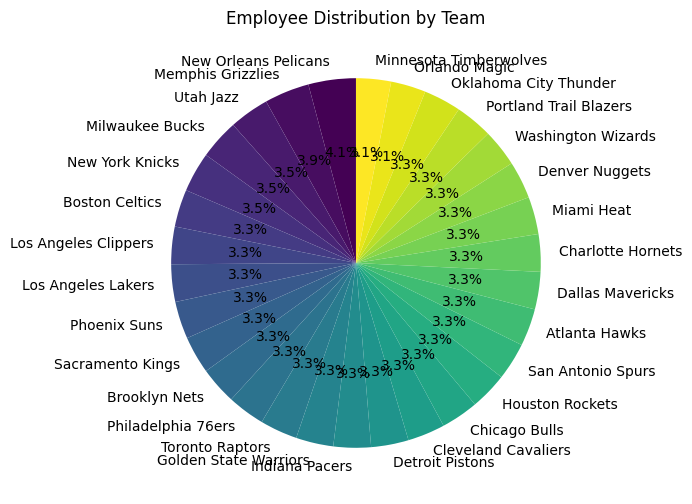

In [30]:
# Pie Chart
plt.figure(figsize=(8, 6))
Team_Counts.plot.pie(autopct='%1.1f%%', startangle=90, colormap='viridis')
plt.title('Employee Distribution by Team')
plt.ylabel('')
plt.show()


### Employee Distribution by Position using Barchart

Employees by Position:
 Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


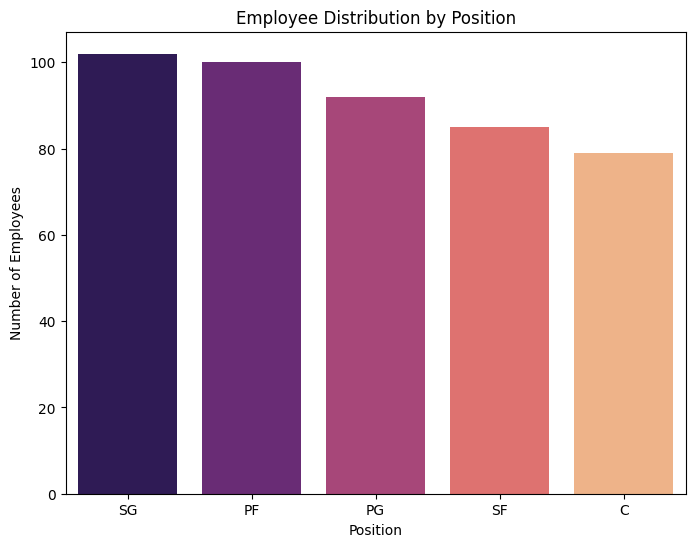

In [35]:
import seaborn as sns
# Grouping by position and count employees
Position_Counts = d['Position'].value_counts()


# Displaying results
print("Employees by Position:\n", Position_Counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=Position_Counts.index, y=Position_Counts.values, palette='magma', hue=Position_Counts.index)
plt.title('Employee Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

### Employee Distribution by Age Group using Histogram

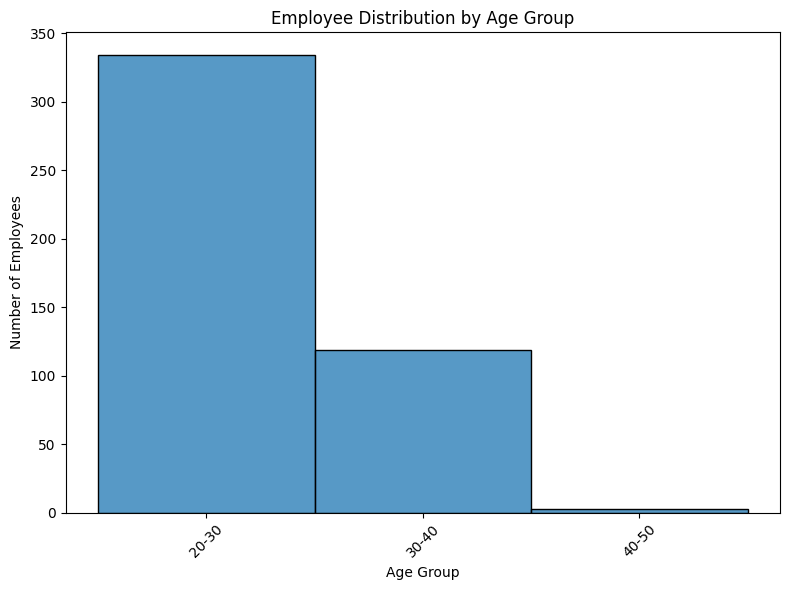

In [36]:
import pandas as p
import seaborn as sns
import matplotlib.pyplot as plt

# Defining age bins and labels
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-30', '30-40', '40-50', '50-60', '60-70']

# Creating age group column
d['age_group'] = p.cut(d['Age'], bins=bins, labels=labels, right=False)

# Using histplot with categorical 'age_group'
plt.figure(figsize=(8, 6))
sns.histplot(data=d, x='age_group', discrete=True, stat='count')
plt.title('Employee Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Salary Expenditure by Team and Position using Barchart

Highest Salary Expenditure by Team: ('Cleveland Cavaliers', np.float64(106988689.0))
Highest Salary Expenditure by Position: ('C', np.float64(466377332.0))


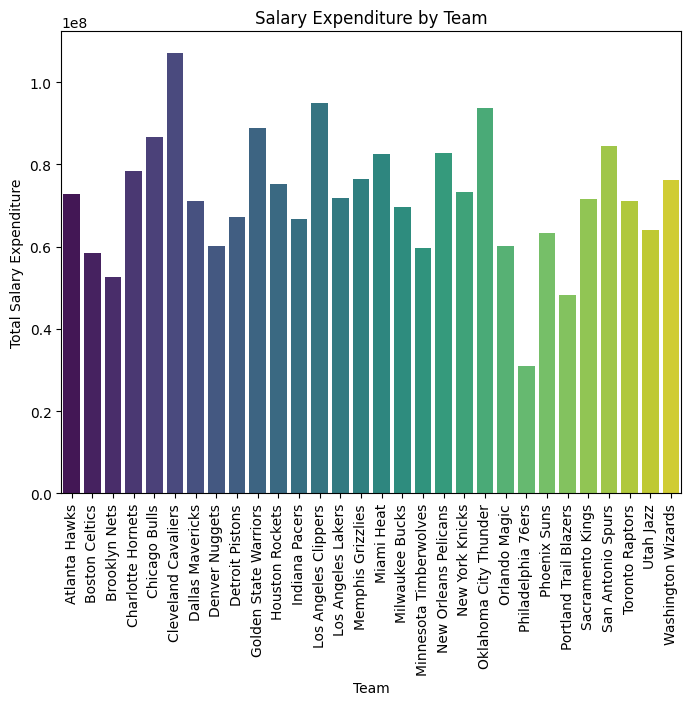

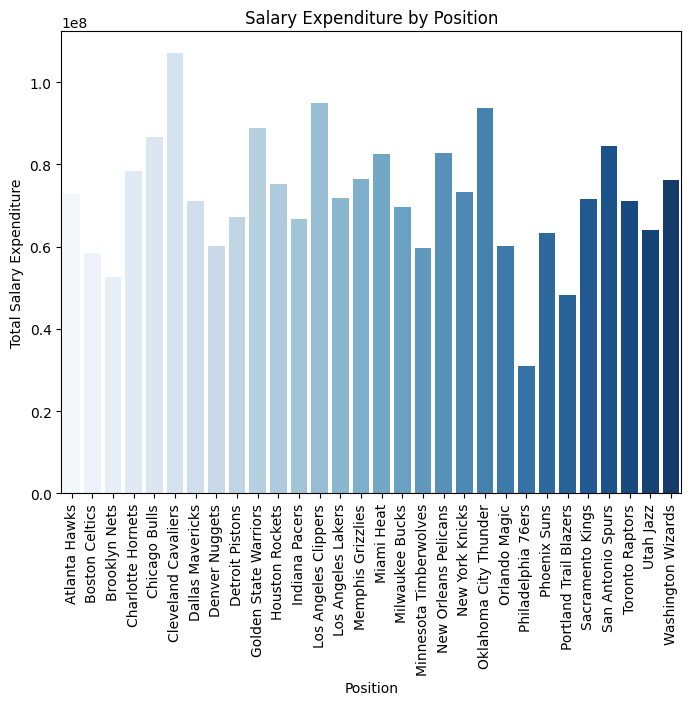

In [37]:
# Grouping by team and calculating total salary expenditure
Team_Salary = d.groupby('Team')['Salary'].sum()

# Grouping by position and calculating total salary expenditure
Position_Salary = d.groupby('Position')['Salary'].sum()

# Identifying highest salary expenditure
Highest_Team_Salary = Team_Salary.idxmax(), Team_Salary.max()
Highest_Position_Salary = Position_Salary.idxmax(), Position_Salary.max()

print("Highest Salary Expenditure by Team:", Highest_Team_Salary)
print("Highest Salary Expenditure by Position:", Highest_Position_Salary)

# Salary expenditure by team (Bar Chart)
team_salary = d.groupby('Team')['Salary'].sum()

plt.figure(figsize=(8, 6))
sns.barplot(x=team_salary.index, y=team_salary.values, palette='viridis', hue=team_salary.index)
plt.title('Salary Expenditure by Team')
plt.xlabel('Team')
plt.ylabel('Total Salary Expenditure')
plt.xticks(rotation=90)
plt.show()

# Salary expenditure by position (Bar Chart)
position_salary = d.groupby('Position')['Salary'].sum()

plt.figure(figsize=(8, 6))

# Assuming you want to group by a category (e.g., `team_salary.index` as hue)
sns.barplot(x=team_salary.index, y=team_salary.values, palette='Blues', hue=team_salary.index)
plt.title('Salary Expenditure by Position')
plt.xlabel('Position')
plt.ylabel('Total Salary Expenditure')
plt.xticks(rotation=90)
plt.show()


### Relation between Age vs Salary in Scatter Plot

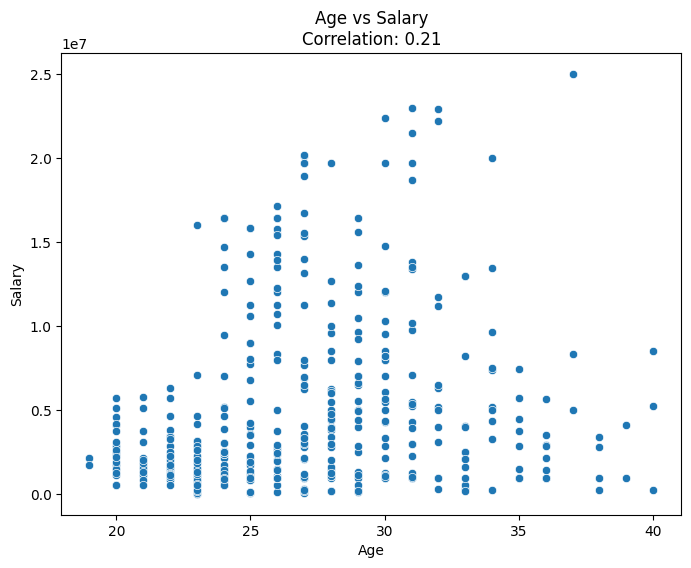

Correlation between Age and Salary: 0.21


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating correlation
Correlation = d['Age'].corr(d['Salary'])

# Visualizing the correlation
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Salary', data=d)
plt.title(f'Age vs Salary\nCorrelation: {Correlation:.2f}')
plt.show()

print(f"Correlation between Age and Salary: {Correlation:.2f}")

## 📌 Insights & Findings 

🔹 Most employees belong to Team New Orleans Pelicans.

🔹 The most common age group is 20-30 years.

🔹 The highest salary expenditure is in Team Cleveland Cavaliers, Position C.

🔹 There is a Positive/Negative correlation between age and salary it is around 0.21.

🔹 Most employees are in the position SG.